In [5]:
import numpy as np
import zipfile
import os
import shutil

In [6]:
# from google.colab import files
# uploaded = files.upload()

# os.makedirs("/root/.kaggle", exist_ok=True)
# for fn in uploaded.keys():
#     os.rename(fn, "/root/.kaggle/kaggle.json")
# os.chmod("/root/.kaggle/kaggle.json", 0o600)

# #!/bin/bash
# !kaggle competitions download -c dogs-vs-cats

In [18]:
PATH = 'data/dogs_vs_cats'

os.makedirs(PATH, exist_ok=True)

with zipfile.ZipFile('dogs-vs-cats.zip') as z:
    z.extractall(PATH)

In [19]:
with zipfile.ZipFile(PATH+'/train.zip') as z:
    z.extractall(PATH)
with zipfile.ZipFile(PATH+'/test1.zip') as z:
    z.extractall(PATH)

In [20]:
TRAIN_PATH='data/dogs_vs_cats/train'
TEST_PATH='data/dogs_vs_cats/test1'

In [21]:
from PIL import Image
import numpy as np
import os

img_path = os.path.join(TRAIN_PATH, "dog.1.jpg")

img = Image.open(img_path)
img_np = np.array(img)

print(img_np.shape)   # (H, W, 3)
print(img_np.dtype)   # uint8

(499, 327, 3)
uint8


In [22]:
from scipy.signal import convolve2d
import matplotlib.pyplot as plt

In [23]:
def conv_rgb(img, kernel) -> np.ndarray:
    out = np.zeros_like(img, dtype=float)
    for c in range(3):
        out[:,:,c] = convolve2d(img[:,:,c], kernel, mode='same')
    return out

In [24]:
kernel = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1]
])

kernels = {
    "sobel_x": np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ]),

    "sobel_y": np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]
    ]),

    "laplacian": np.array([
        [ 0, -1,  0],
        [-1,  4, -1],
        [ 0, -1,  0]
    ]),

    "gaussian_blur": np.array([
        [1, 2, 1],
        [2, 4, 2],
        [1, 2, 1]
    ]) / 16,

    "sharpen": np.array([
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]
    ])
}


In [25]:
def show_compare(img, kernel, name):
    out = conv_rgb(img, kernel)
    out = np.clip(out,0,255).astype(np.uint8)

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(out)
    plt.title(name)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

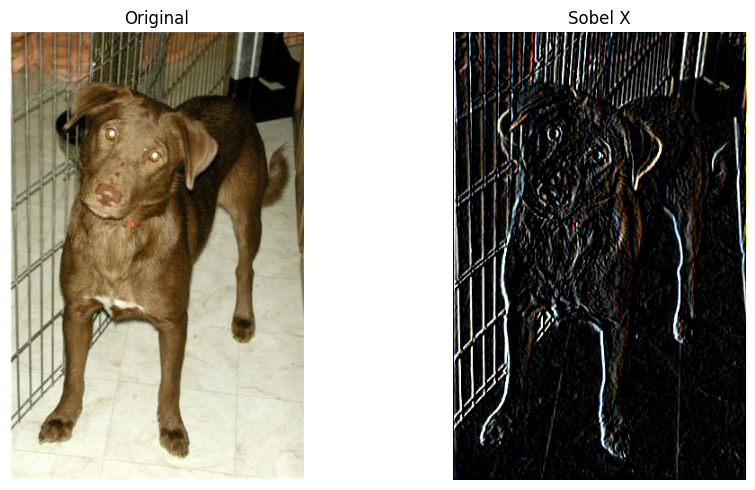

In [26]:
show_compare(img_np, kernels["sobel_x"], "Sobel X")

In [27]:
img_path = os.path.join(TRAIN_PATH, "cat.1.jpg")

img = Image.open(img_path)
img_np = np.array(img)

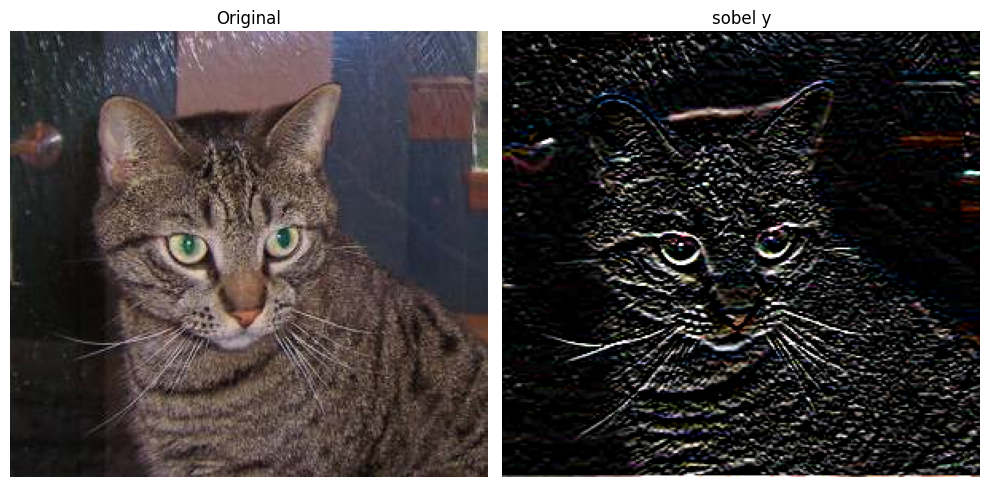

In [28]:
show_compare(img_np, kernels["sobel_y"], "sobel y")

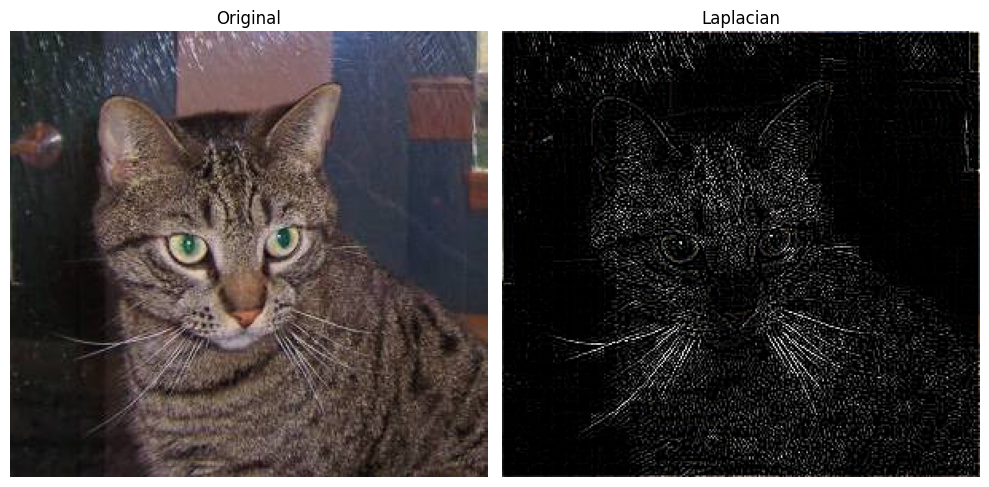

In [29]:
show_compare(img_np, kernels["laplacian"], "Laplacian")

In [30]:
laplacian_8 = np.array([
    [-1,-1,-1],
    [-1, 8,-1],
    [-1,-1,-1]
])


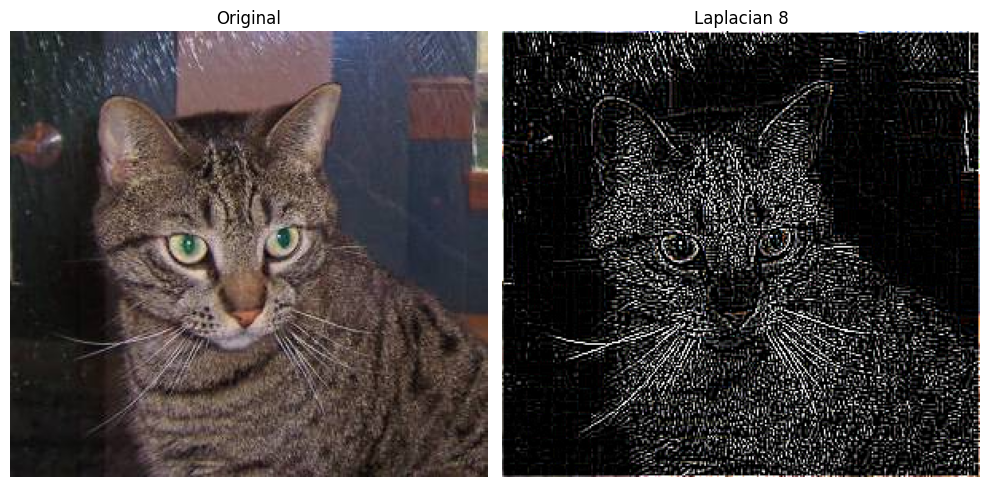

In [31]:
show_compare(img_np, laplacian_8, "Laplacian 8")

(np.float64(-0.5), np.float64(299.5), np.float64(279.5), np.float64(-0.5))

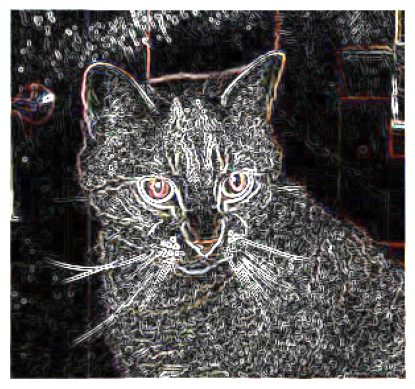

In [32]:
gx = conv_rgb(img_np, kernels["sobel_x"])
gy = conv_rgb(img_np, kernels["sobel_y"])

edge = np.sqrt(gx**2 + gy**2)
edge = np.clip(edge,0,255).astype(np.uint8)

plt.imshow(edge)
plt.axis("off")

In [33]:
import cv2
edges = cv2.Canny(img_np, 100, 200)


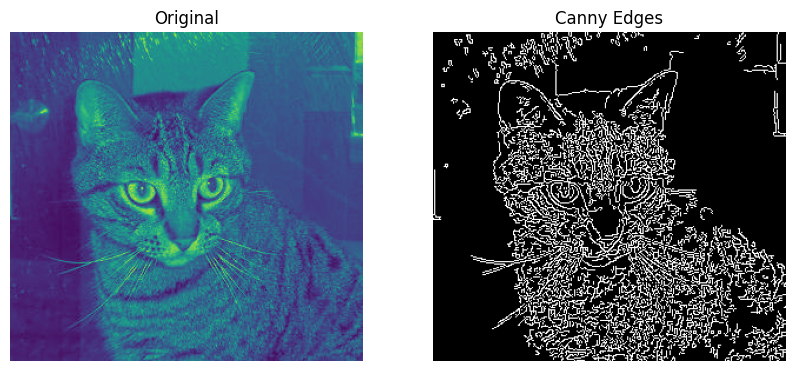

In [34]:
img = cv2.imread(os.path.join(TRAIN_PATH, 'cat.1.jpg'))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Canny edge detection
edges = cv2.Canny(gray, threshold1=100, threshold2=200)

# show side by side
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.show()

In [35]:
import torch
from torchvision import transforms

In [36]:
def getDevice():
  if torch.cuda.is_available():
    return torch.device("cuda")
  elif torch.mps.is_available():
    return torch.device("mps")
  return torch.device("cpu")

device = getDevice()
device

device(type='cuda')

In [37]:
from torch.utils.data import Dataset, DataLoader

In [38]:
TEST_PATH='data/dogs_vs_cats/test1'
batch_size=32

In [39]:
# len(os.listdir(DOG_PATH)), len(os.listdir(CAT_PATH)), len(os.listdir(TEST_PATH)), img_np.shape
# (12500, 12500, 12500, (280, 300, 3))

In [40]:
class DogCatsDataset(Dataset):
    def __init__(self, root_dir, transform=None, has_labels=False):
        self.root_dir = root_dir
        self.transform = transform
        self.images = os.listdir(root_dir)
        self.has_labels = has_labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_name = self.images[index]

        img_path = os.path.join(self.root_dir, img_name)
        image = Image.open(img_path)

        if self.transform:
            image = self.transform(image)

        if self.has_labels:
            # dog - 1, cat 0
            label = 1 if img_name.startswith("dog") else 0
            return image, label
        return image, img_name

In [41]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
type(transform)

torchvision.transforms.transforms.Compose

In [42]:
from torch.utils.data import random_split

full_dataset = DogCatsDataset(
    TRAIN_PATH,
    transform=transform,
    has_labels=True
)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size]
)
# test_dataset = DogCatsDataset(TEST_PATH, transform=transform)

In [43]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=32,shuffle=False)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [44]:
train_loader.__iter__().__next__()[0].shape, len(train_loader)

(torch.Size([32, 3, 224, 224]), 625)

In [46]:
782*32, train_dataset.dataset.images.__len__()

(25024, 25000)

In [47]:
import torch.nn as nn
import torch.nn.functional as F

In [48]:
class Network(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 5)    # 32, 16, 220, 220
        self.pool1 = nn.MaxPool2d(2,2)      # 32, 16, 110, 110

        self.conv2 = nn.Conv2d(16, 64, 5)   # 32, 64, 106, 106
        self.pool2 = nn.MaxPool2d(2,2)      # 32, 64, 53, 53

        self.fc1 = nn.Linear(64*53*53, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [49]:
net = Network()
net = net.to(device)

In [50]:
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [58]:
for epoch in range(20):
    running_loss = 0.0

    for i, data in enumerate(train_loader, 0):
        img, label = data
        optimizer.zero_grad()
        # print(type(input))
        img = img.to(device)
        label = label.float().unsqueeze(1).to(device)

        ouput = net(img)
        loss = criterion(ouput, label)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/20] Loss: {epoch_loss:.4f}")

Epoch [1/20] Loss: 0.5149
Epoch [2/20] Loss: 0.4761
Epoch [3/20] Loss: 0.4379
Epoch [4/20] Loss: 0.3996
Epoch [5/20] Loss: 0.3531
Epoch [6/20] Loss: 0.3054
Epoch [7/20] Loss: 0.2566
Epoch [8/20] Loss: 0.2017
Epoch [9/20] Loss: 0.1507
Epoch [10/20] Loss: 0.1035
Epoch [11/20] Loss: 0.0644
Epoch [12/20] Loss: 0.0309
Epoch [13/20] Loss: 0.0164
Epoch [14/20] Loss: 0.0096
Epoch [15/20] Loss: 0.0057
Epoch [16/20] Loss: 0.0034
Epoch [17/20] Loss: 0.0073
Epoch [18/20] Loss: 0.0194
Epoch [19/20] Loss: 0.0066
Epoch [20/20] Loss: 0.0040


In [59]:
PATH = './cifar_net.pt'
torch.save(net.state_dict(), PATH)

In [62]:
net.eval()

correct, total= 0,0

with torch.no_grad():
    for img, label in val_loader:
        img = img.to(device)
        output = net(img)

        pred = (torch.sigmoid(output) > 0.5).cpu().squeeze(1)
        correct += (pred.cpu() == label).sum().item()
        total += label.size(0)

accuracy = correct/total
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 0.78%
